# Brazilian E-Commerce Data Analysis

## Project Overview

This project performs exploratory data analysis (EDA) on the Brazilian e-commerce dataset from Olist.

The analysis explores customer distribution, sales and revenue trends, product categories, payment behavior, delivery performance, customer reviews, and order cancellations.

## Objectives

- Analyze overall sales and revenue performance
- Identify the states with the highest number of customers and revenue
- Analyze product category performance and customer reviews
- Understand payment methods and installment behavior
- Investigate the relationship between delivery time and customer satisfaction
- Analyze order cancellations and their distribution

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
os.makedirs("output", exist_ok=True)


In [2]:
customers = pd.read_csv("Data/olist_customers_dataset.csv")

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.shape

(99441, 5)

In [5]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [7]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [8]:
customers["customer_unique_id"].duplicated().sum()

np.int64(3345)

In [9]:
customers[customers["customer_unique_id"].duplicated(keep=False)].sort_values("customer_unique_id").head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
35608,24b0e2bd287e47d54d193e7bbb51103f,00172711b30d52eea8b313a7f2cced02,45200,jequie,BA
19299,1afe8a9c67eec3516c09a8bdcc539090,00172711b30d52eea8b313a7f2cced02,45200,jequie,BA
20023,1b4a75b3478138e99902678254b260f4,004288347e5e88a27ded2bb23747066c,26220,nova iguacu,RJ
22066,f6efe5d5c7b85e12355f9d5c3db46da2,004288347e5e88a27ded2bb23747066c,26220,nova iguacu,RJ
72451,49cf243e0d353cd418ca77868e24a670,004b45ec5c64187465168251cd1c9c2f,57055,maceio,AL
87012,d95f60d70d9ea9a7fe37c53c931940bb,004b45ec5c64187465168251cd1c9c2f,57035,maceio,AL
36269,8ac44e9c15d396b8c3c7cbab0fff4536,0058f300f57d7b93c477a131a59b36c3,41370,salvador,BA
61403,f530197ea86ced9488a03d055e118ebf,0058f300f57d7b93c477a131a59b36c3,40731,salvador,BA
87414,cbb68c721ba9ddb30d8a490cc1897fa1,00a39521eb40f7012db50455bf083460,72595,brasilia,DF
54881,876356df457f952458a764348e1858bc,00a39521eb40f7012db50455bf083460,72595,brasilia,DF


In [10]:
customers["customer_unique_id"].nunique()

96096

In [11]:
orders = pd.read_csv("Data/olist_orders_dataset.csv")

In [12]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
orders.shape

(99441, 8)

In [14]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [15]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [16]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [17]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [18]:
orders["customer_id"].isin(customers["customer_id"]).value_counts()

customer_id
True    99441
Name: count, dtype: int64

In [19]:
orders["customer_id"].value_counts().head(10)

customer_id
9ef432eb6251297304e76186b10a928d    1
b0830fb4747a6c6d20dea0b8c802d7ef    1
41ce2a54c0b03bf3443c3d931a367089    1
f88197465ea7920adcdbec7375364d82    1
8ab97904e6daea8866dbdbc4fb7aad2c    1
503740e9ca751ccdda7ba28e9ab8f608    1
ed0271e0b7da060a393796590e7b737a    1
9bdf08b4b3b52b5526ff42d37d47f222    1
f54a9f0e6b351c431402b8461ea51999    1
31ad1d1b63eb9962463f764d4e6e0c9d    1
Name: count, dtype: int64

In [20]:
order_items = pd.read_csv("Data/olist_order_items_dataset.csv")

In [21]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [22]:
order_items.shape

(112650, 7)

In [23]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [24]:
order_items["order_id"].duplicated().sum()

np.int64(13984)

In [25]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [26]:
order_items["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [27]:
order_items["price"].min()

np.float64(0.85)

In [28]:
order_items["price"].max()

np.float64(6735.0)

In [29]:
order_items["order_item_id"].value_counts().sort_index()

order_item_id
1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

In [30]:
order_items.duplicated(subset=["order_id", "order_item_id"]).sum()

np.int64(0)

In [31]:
products = pd.read_csv("Data/olist_products_dataset.csv")

In [32]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [33]:
products.shape

(32951, 9)

In [34]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [35]:
products["product_id"].duplicated().sum()

np.int64(0)

In [36]:
products["product_category_name"].nunique()

73

In [37]:
products["product_category_name"].isna().sum()

np.int64(610)

In [38]:
payments = pd.read_csv("Data/olist_order_payments_dataset.csv")

In [39]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [40]:
payments.shape

(103886, 5)

In [41]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [42]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [43]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [44]:
payments["order_id"].duplicated().sum()

np.int64(4446)

In [45]:
payments["order_id"].nunique()

99440

In [46]:
payments.groupby("order_id").size().value_counts().sort_index()

1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64

In [47]:
orders[~orders["order_id"].isin(payments["order_id"])]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00


In [48]:
orders[~orders["order_id"].isin(payments["order_id"])]["order_status"]

30710    delivered
Name: order_status, dtype: str

In [49]:
reviews = pd.read_csv("Data/olist_order_reviews_dataset.csv")

In [50]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [51]:
reviews.shape

(99224, 7)

In [52]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [53]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [54]:
reviews["review_comment_message"].isna().sum()

np.int64(58247)

In [55]:
reviews["review_id"].duplicated().sum()

np.int64(814)

In [56]:
reviews[reviews["review_id"].duplicated(keep=False)].sort_values("review_id").head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44


In [57]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [58]:
reviews["order_id"].nunique()

98673

In [59]:
reviews.groupby("order_id").size().value_counts().sort_index()

1    98126
2      543
3        4
Name: count, dtype: int64

In [60]:
reviews.groupby("order_id").size().sort_values(ascending=False).head(10)

order_id
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
7f13a20e25350f4a55fb2a7c9a2e8d88    2
44aa72f4eebc8c0ff7a3636f6369201b    2
7b994fc7c7528d2098eebcb19d18ce7e    2
34de5f7952fbd04a9a1e5d7001b014b5    2
6318d8c5f6857de384c0b3186d036457    2
09a38776c4e31230864f867821174daa    2
dtype: int64

In [61]:
sellers = pd.read_csv("Data/olist_sellers_dataset.csv")

In [62]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [63]:
sellers.shape

(3095, 4)

In [64]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [65]:
sellers["seller_id"].duplicated().sum()

np.int64(0)

In [66]:
sellers["seller_state"].value_counts().head(10)

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64

In [67]:
print("CUSTOMERS")
print(customers.isna().sum())

print("\nORDERS")
print(orders.isna().sum())

print("\nORDER ITEMS")
print(order_items.isna().sum())

print("\nPRODUCTS")
print(products.isna().sum())

print("\nPAYMENTS")
print(payments.isna().sum())

print("\nREVIEWS")
print(reviews.isna().sum())

print("\nSELLERS")
print(sellers.isna().sum())

CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

ORDER ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

PRODUCTS
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm   

In [68]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

In [69]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [70]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

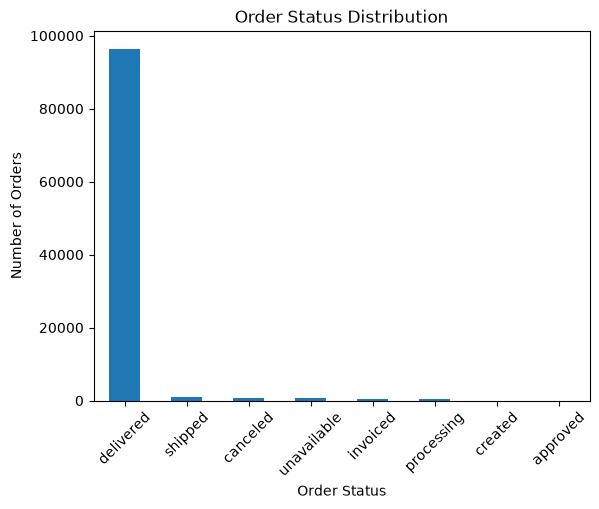

In [71]:

orders["order_status"].value_counts().plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.savefig("output/order_status_distribution.png", bbox_inches="tight")
plt.show()

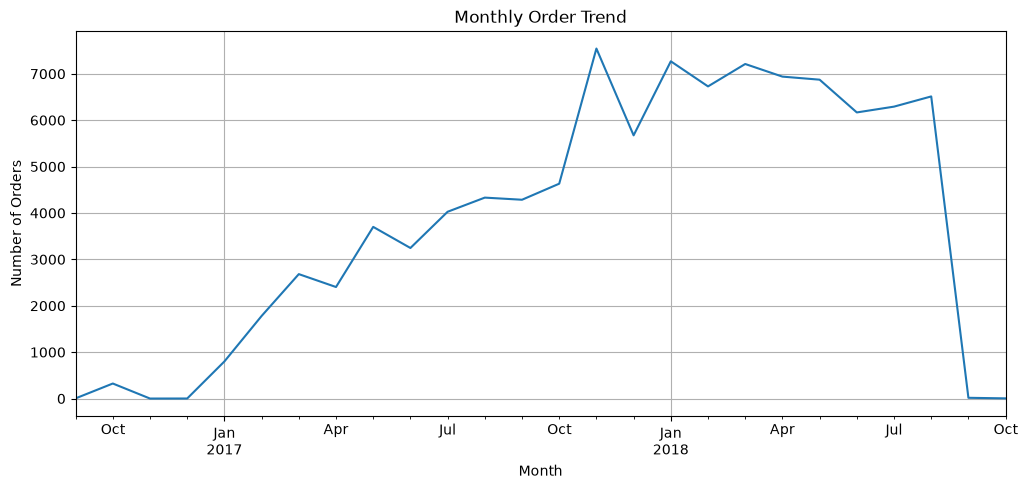

In [72]:
monthly_orders = orders.set_index(
    "order_purchase_timestamp"
).resample("ME").size()

monthly_orders.plot(figsize=(12, 5))

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)

plt.savefig("output/monthly_order_trend.png", bbox_inches="tight")
plt.show()
plt.close()

In [73]:
sales = order_items.merge(
    orders[["order_id", "order_purchase_timestamp", "order_status"]],
    on="order_id",
    how="left"
)

sales["total_value"] = sales["price"] + sales["freight_value"]

sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_status,total_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02,delivered,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06,delivered,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31,delivered,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35,delivered,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51,delivered,218.04


In [74]:
sales["total_value"].sum()

np.float64(15843553.24)

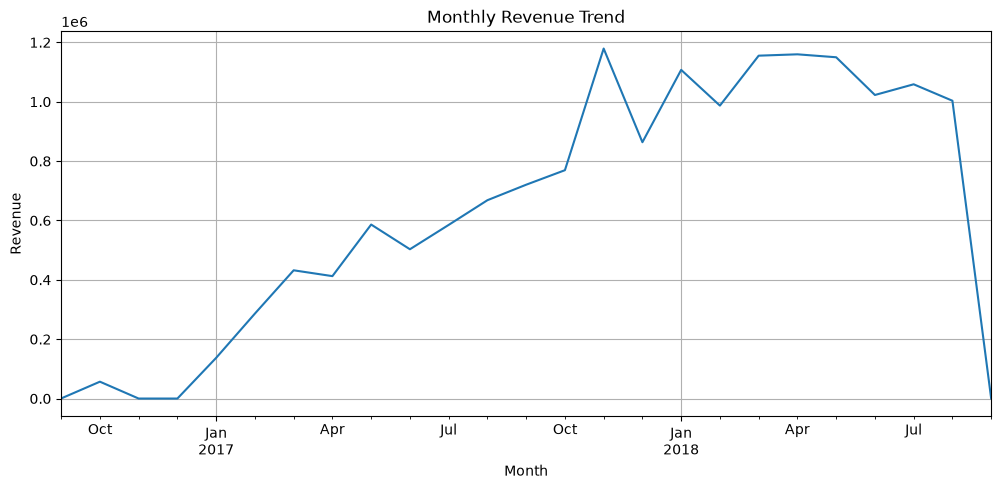

In [75]:
monthly_revenue = sales.set_index(
    "order_purchase_timestamp"
)["total_value"].resample("ME").sum()

monthly_revenue.plot(figsize=(12, 5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.savefig("output/monthly_revenue_trend.png", bbox_inches="tight")
plt.show()
plt.close()

In [76]:
sales_products = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_revenue = (
    sales_products
    .groupby("product_category_name")["total_value"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241681.72
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
moveis_decoracao           902511.79
utilidades_domesticas      778397.77
cool_stuff                 719329.95
automotivo                 685384.32
ferramentas_jardim         584219.21
Name: total_value, dtype: float64

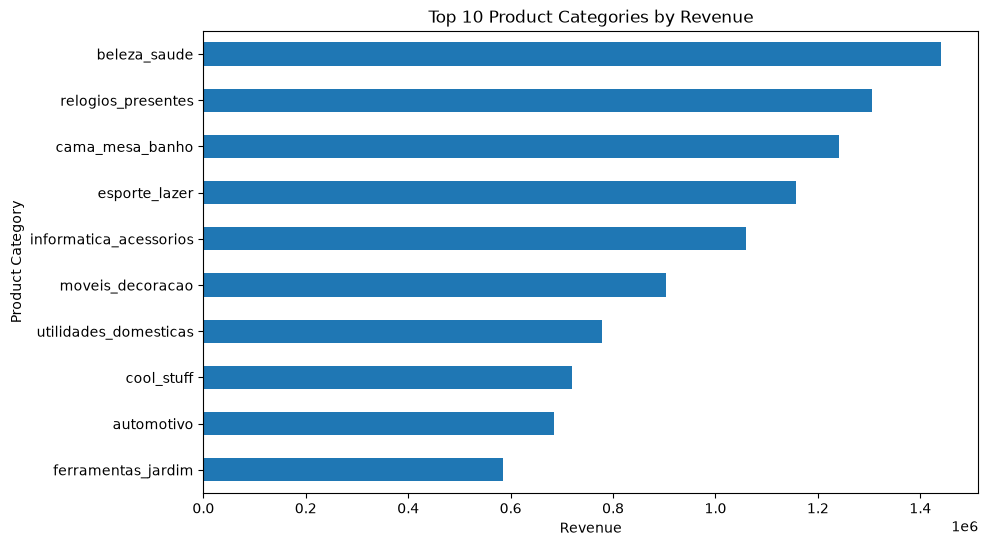

In [77]:
sales_products = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_revenue = (
    sales_products.groupby("product_category_name")["total_value"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.savefig("output/top_10_product_categories_revenue.png", bbox_inches="tight")
plt.show()
plt.close()

In [78]:
customer_state = customers["customer_state"].value_counts()

customer_state.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

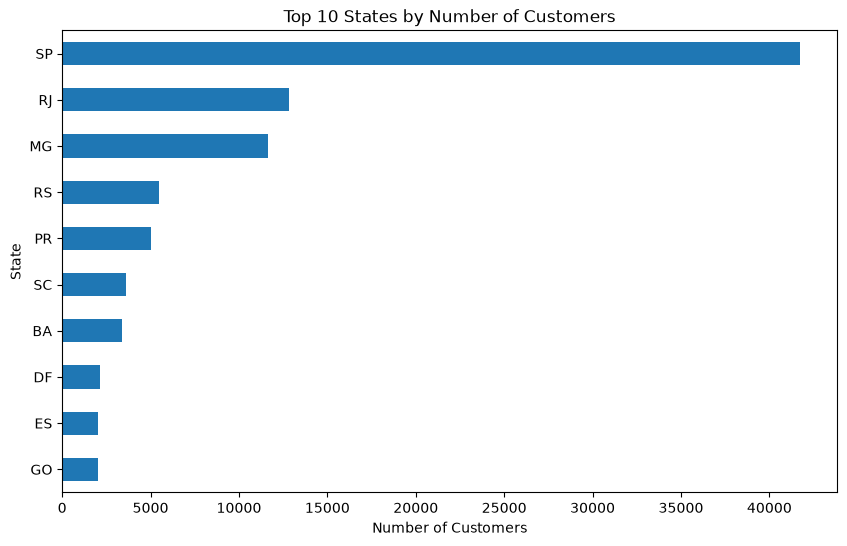

In [79]:
customer_state = customers["customer_state"].value_counts()

customer_state.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 States by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("State")

plt.savefig("output/top_10_states_customers.png", bbox_inches="tight")
plt.show()
plt.close()

In [80]:
orders[["order_id", "order_purchase_timestamp", "order_status"]]

,order_id,order_purchase_timestamp,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,delivered
...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,delivered
99437,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,delivered
99438,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,delivered
99439,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,delivered


In [81]:
sales = order_items.merge(
    orders[[
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_status"
    ]],
    on="order_id",
    how="left"
)

sales["total_value"] = sales["price"] + sales["freight_value"]

sales = sales.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_status,total_value,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered,72.19,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered,259.83,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered,216.87,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered,25.78,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,delivered,218.04,SP


In [82]:
state_revenue = (
    sales.groupby("customer_state")["total_value"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: total_value, dtype: float64

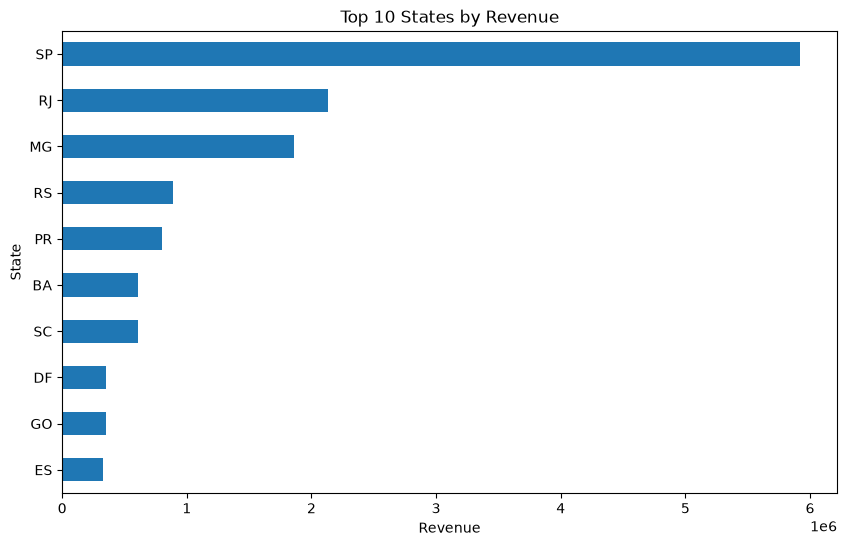

In [83]:
state_revenue = (
    sales.groupby("customer_state")["total_value"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.savefig("output/top_10_states_revenue.png", bbox_inches="tight")
plt.show()
plt.close()

In [84]:
state_analysis = sales.groupby("customer_state").agg(
    customers=("customer_id", "nunique"),
    revenue=("total_value", "sum")
)

state_analysis["avg_revenue_per_customer"] = (
    state_analysis["revenue"] / state_analysis["customers"]
)

state_analysis.sort_values(
    "avg_revenue_per_customer",
    ascending=False
).head(10)

,customers,revenue,avg_revenue_per_customer
customer_state,,,
PB,532,140987.81,265.014680
AC,81,19669.70,242.835802
AP,68,16262.80,239.158824
AL,411,96229.40,234.134793
RO,247,57558.02,233.028421
PA,970,217647.11,224.378464
TO,279,61354.42,219.908315
PI,493,108132.28,219.335254
RR,46,10064.62,218.796087


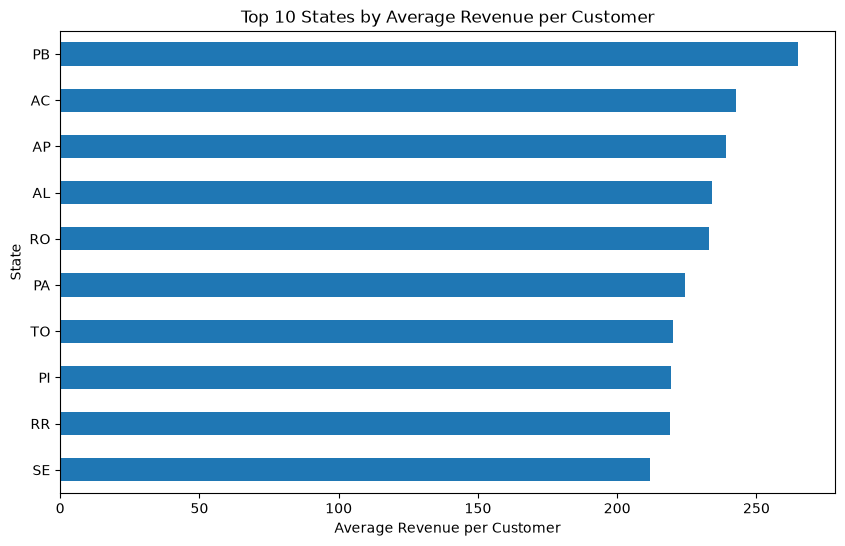

In [85]:
state_analysis = sales.groupby("customer_state").agg(
    customers=("customer_id", "nunique"),
    total_revenue=("total_value", "sum")
)

state_analysis["avg_revenue_per_customer"] = (
    state_analysis["total_revenue"] /
    state_analysis["customers"]
)

state_analysis["avg_revenue_per_customer"].sort_values(
    ascending=False
).head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 States by Average Revenue per Customer")
plt.xlabel("Average Revenue per Customer")
plt.ylabel("State")

plt.savefig("output/top_states_avg_revenue.png", bbox_inches="tight")
plt.show()
plt.close()

In [86]:
reliable_states = state_analysis[
    state_analysis["customers"] >= 500
].sort_values(
    "avg_revenue_per_customer",
    ascending=False
)

reliable_states.head(10)

,customers,total_revenue,avg_revenue_per_customer
customer_state,,,
PB,532,140987.81,265.014680
PA,970,217647.11,224.378464
CE,1327,275606.30,207.691258
MT,903,186168.96,206.167176
MA,740,151171.99,204.286473
PE,1648,322237.69,195.532579
MS,709,135956.67,191.758350
BA,3358,611506.67,182.104428
GO,2007,347706.93,173.247100


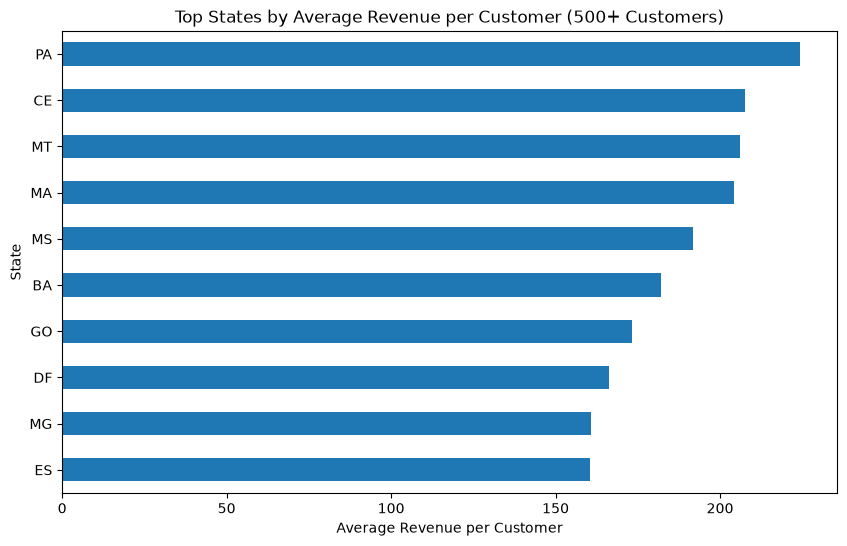

In [87]:
reliable_states = state_analysis[
    state_analysis["customers"] >= 500
]

reliable_states.head(10)["avg_revenue_per_customer"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top States by Average Revenue per Customer (500+ Customers)")
plt.xlabel("Average Revenue per Customer")
plt.ylabel("State")

plt.savefig(
    "output/top_states_avg_revenue_500_customers.png",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [88]:
payment_analysis = (
    payments.groupby("payment_type")["payment_value"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

payment_analysis

,count,sum,mean
payment_type,,,
credit_card,76795,12542084.19,163.319021
boleto,19784,2869361.27,145.034435
voucher,5775,379436.87,65.703354
debit_card,1529,217989.79,142.570170
not_defined,3,0.00,0.000000


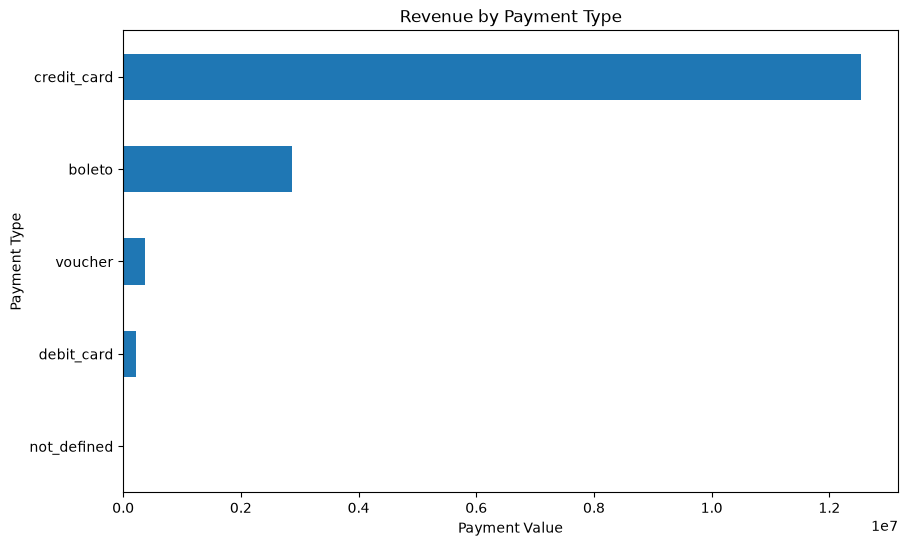

In [89]:
payment_analysis = (
    payments.groupby("payment_type")["payment_value"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

payment_analysis["sum"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Revenue by Payment Type")
plt.xlabel("Payment Value")
plt.ylabel("Payment Type")

plt.savefig("output/revenue_by_payment_type.png", bbox_inches="tight")
plt.show()
plt.close()

In [90]:
payment_analysis = payments.groupby("payment_type").agg(
    transactions=("payment_type", "count"),
    total_value=("payment_value", "sum"),
    avg_value=("payment_value", "mean"),
    avg_installments=("payment_installments", "mean")
).sort_values("total_value", ascending=False)

payment_analysis

,transactions,total_value,avg_value,avg_installments
payment_type,,,,
credit_card,76795,12542084.19,163.319021,3.507155
boleto,19784,2869361.27,145.034435,1.000000
voucher,5775,379436.87,65.703354,1.000000
debit_card,1529,217989.79,142.570170,1.000000
not_defined,3,0.00,0.000000,1.000000


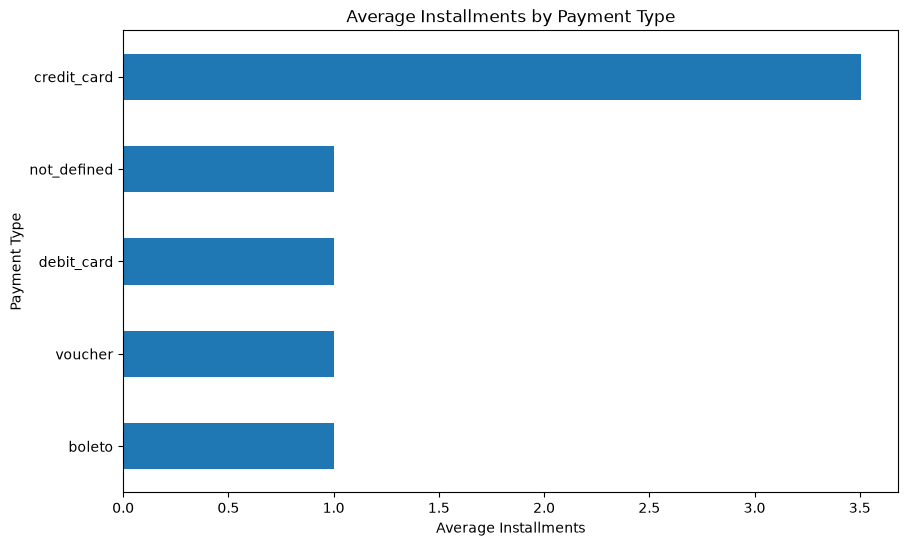

In [91]:
payment_analysis = payments.groupby("payment_type").agg(
    transactions=("payment_type", "count"),
    total_value=("payment_value", "sum"),
    avg_value=("payment_value", "mean"),
    avg_installments=("payment_installments", "mean")
).sort_values("total_value", ascending=False)

payment_analysis["avg_installments"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Installments by Payment Type")
plt.xlabel("Average Installments")
plt.ylabel("Payment Type")

plt.savefig(
    "output/average_installments_payment_type.png",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [92]:
installment_analysis = payments.groupby("payment_installments").agg(
    transactions=("payment_value", "count"),
    total_value=("payment_value", "sum"),
    avg_payment_value=("payment_value", "mean")
).sort_values("transactions", ascending=False)

installment_analysis.head(10)

,transactions,total_value,avg_payment_value
payment_installments,,,
1,52546,5907233.36,112.420229
2,12413,1579283.03,127.228150
3,10461,1491103.80,142.539317
4,7098,1163907.61,163.976840
10,5328,2211577.34,415.085837
5,5239,961174.30,183.465222
8,4268,1313423.34,307.737427
6,3920,822611.81,209.849952
7,1626,305157.39,187.673672


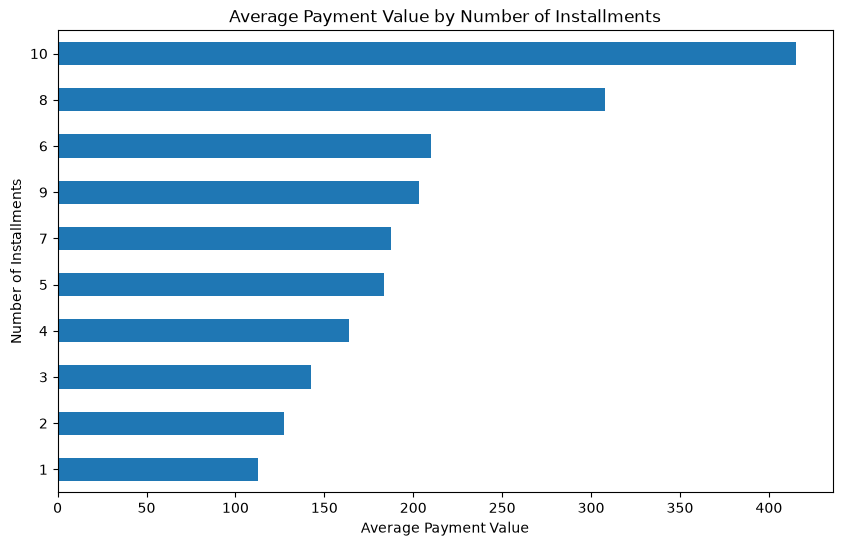

In [93]:
installment_analysis = payments.groupby(
    "payment_installments"
).agg(
    transactions=("payment_value", "count"),
    total_value=("payment_value", "sum"),
    avg_payment_value=("payment_value", "mean")
).sort_values(
    "transactions",
    ascending=False
)

installment_analysis.head(10)["avg_payment_value"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Payment Value by Number of Installments")
plt.xlabel("Average Payment Value")
plt.ylabel("Number of Installments")

plt.savefig(
    "output/average_payment_value_installments.png",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [94]:
installment_analysis.sort_values(
    "transactions",
    ascending=False
).head(10)

,transactions,total_value,avg_payment_value
payment_installments,,,
1,52546,5907233.36,112.420229
2,12413,1579283.03,127.228150
3,10461,1491103.80,142.539317
4,7098,1163907.61,163.976840
10,5328,2211577.34,415.085837
5,5239,961174.30,183.465222
8,4268,1313423.34,307.737427
6,3920,822611.81,209.849952
7,1626,305157.39,187.673672


In [95]:
review_analysis = reviews.merge(
    orders[[
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]],
    on="order_id",
    how="left"
)

review_analysis["delivery_days"] = (
    review_analysis["order_delivered_customer_date"]
    - review_analysis["order_purchase_timestamp"]
).dt.days

review_analysis.groupby("review_score")["delivery_days"].mean()

review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_days, dtype: float64

In [96]:
review_analysis["delivery_performance"] = np.where(
    review_analysis["order_delivered_customer_date"]
    <= review_analysis["order_estimated_delivery_date"],
    "On Time",
    "Late"
)

review_analysis.groupby(
    "delivery_performance"
)["review_score"].mean()

delivery_performance
Late       2.348192
On Time    4.293578
Name: review_score, dtype: float64

In [97]:
review_payment = reviews.merge(
    payments[["order_id", "payment_value"]],
    on="order_id",
    how="left"
)

review_payment.groupby("review_score")["payment_value"].mean()

review_score
1    186.388143
2    163.374048
3    145.134606
4    147.976925
5    149.697435
Name: payment_value, dtype: float64

In [98]:
review_payment[[
    "review_score",
    "payment_value"
]].corr()

,review_score,payment_value
review_score,1.000000,-0.046513
payment_value,-0.046513,1.000000


In [99]:
category_reviews = review_analysis.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="left"
).merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_review_score = (
    category_reviews.groupby("product_category_name")["review_score"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

category_review_score.head(10)

,mean,count
product_category_name,,
cds_dvds_musicais,4.642857,14
fashion_roupa_infanto_juvenil,4.500000,8
livros_interesse_geral,4.446266,549
construcao_ferramentas_ferramentas,4.444444,99
flores,4.419355,31
livros_importados,4.400000,60
livros_tecnicos,4.368421,266
alimentos_bebidas,4.315412,279
malas_acessorios,4.315257,1088


In [100]:
reliable_category_reviews = (
    category_review_score[
        category_review_score["count"] >= 100
    ]
    .sort_values("mean", ascending=False)
)

reliable_category_reviews.head(10)

,mean,count
product_category_name,,
livros_interesse_geral,4.446266,549
livros_tecnicos,4.368421,266
alimentos_bebidas,4.315412,279
malas_acessorios,4.315257,1088
fashion_calcados,4.233716,261
alimentos,4.218182,495
papelaria,4.193857,2507
pet_shop,4.185147,1939
pcs,4.175000,200


In [101]:
reliable_category_reviews.tail(10).sort_values("mean")

,mean,count
product_category_name,,
moveis_escritorio,3.493183,1687
fashion_roupa_masculina,3.641221,131
telefonia_fixa,3.683206,262
audio,3.825485,361
casa_conforto,3.829885,435
construcao_ferramentas_seguranca,3.844560,193
cama_mesa_banho,3.895663,11137
moveis_decoracao,3.903493,8331
moveis_sala,3.904382,502


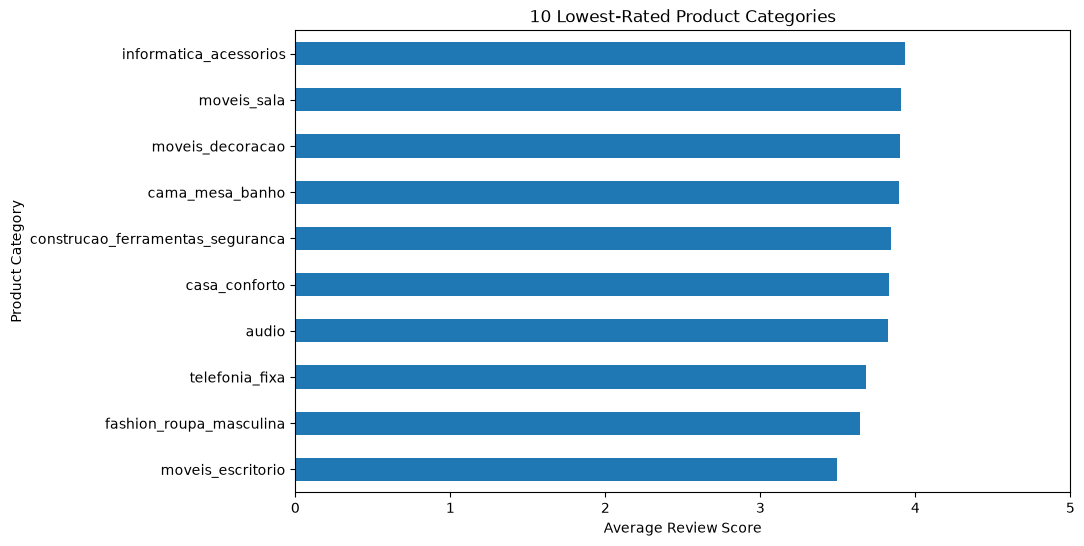

In [102]:
reliable_category_reviews.tail(10).sort_values("mean").plot(
    kind="barh",
    y="mean",
    figsize=(10, 6),
    legend=False
)

plt.title("10 Lowest-Rated Product Categories")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")
plt.xlim(0, 5)

plt.savefig(
    "output/lowest_rated_product_categories.png",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [103]:
review_analysis[[
    "review_score",
    "delivery_days"
]].corr()

,review_score,delivery_days
review_score,1.00000,-0.33366
delivery_days,-0.33366,1.00000


In [104]:
review_analysis.groupby("review_score")["delivery_days"].mean()

review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_days, dtype: float64

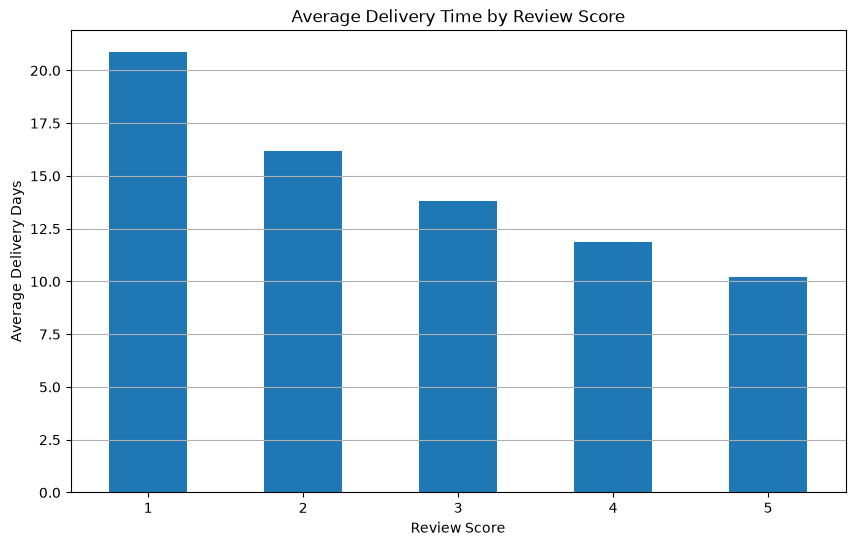

In [105]:
review_analysis.groupby("review_score")["delivery_days"].mean().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.savefig(
    "output/average_delivery_time_review_score.png",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [106]:
order_status_analysis = orders["order_status"].value_counts()

order_status_analysis

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

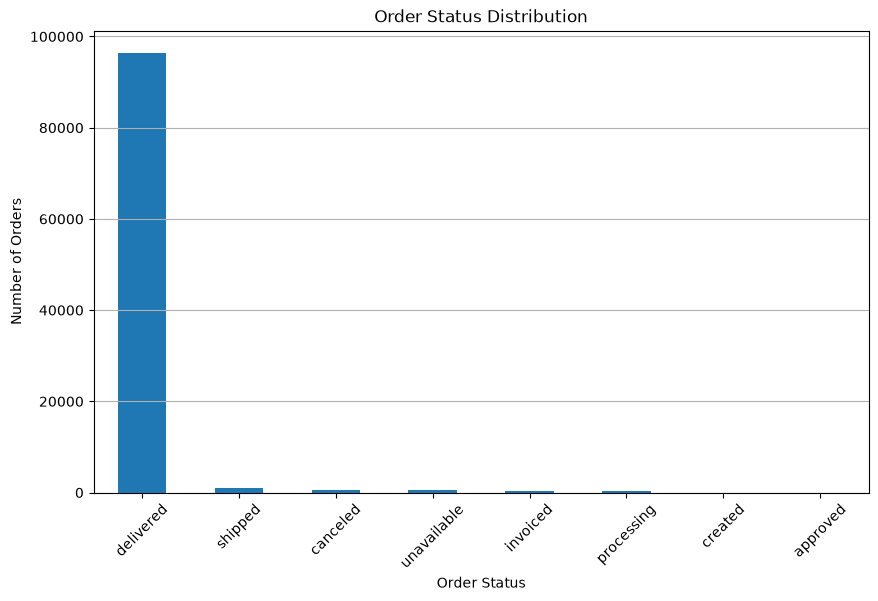

In [107]:
order_status_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.savefig("output/order_status_distribution.png", bbox_inches="tight")

plt.show()
plt.close()

In [108]:
total_orders = len(orders)

cancelled_orders = (orders["order_status"] == "canceled").sum()

cancellation_rate = (cancelled_orders / total_orders) * 100

print("Total Orders:", total_orders)
print("Cancelled Orders:", cancelled_orders)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Total Orders: 99441
Cancelled Orders: 625
Cancellation Rate: 0.63 %


In [109]:
cancellation_by_state = (
    orders[orders["order_status"] == "canceled"]
    .groupby("customer_id")
    .size()
    .sort_values(ascending=False)
)

cancellation_by_state.head(10)

customer_id
002b5342c72978cf0aba6aae1f5d5293    1
00f8a4bbb515bfe8f84f9cfa45621250    1
01866d949d55c81c28d255114948b72b    1
019f5bb93ed18dd059051c3f81abe394    1
032a544bbe984490f6ff7450e3c8b0bc    1
0337719c3caba8187a276942d35347fd    1
033f5ddbb536a477e81abd786f23f452    1
0340b2de09f18a986fea9f26cc7b2d9c    1
040d94f8ba8ca26014bd6f7e8a6e0c0d    1
045d8fcab59f603256eefe86e45f0350    1
dtype: int64

In [110]:
cancelled_orders = orders[orders["order_status"] == "canceled"]

cancelled_with_state = cancelled_orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

cancellation_by_state = (
    cancelled_with_state["customer_state"]
    .value_counts()
    .head(10)
)

cancellation_by_state

customer_state
SP    327
RJ     86
MG     64
RS     25
PR     22
SC     19
BA     16
GO     13
ES      9
CE      7
Name: count, dtype: int64

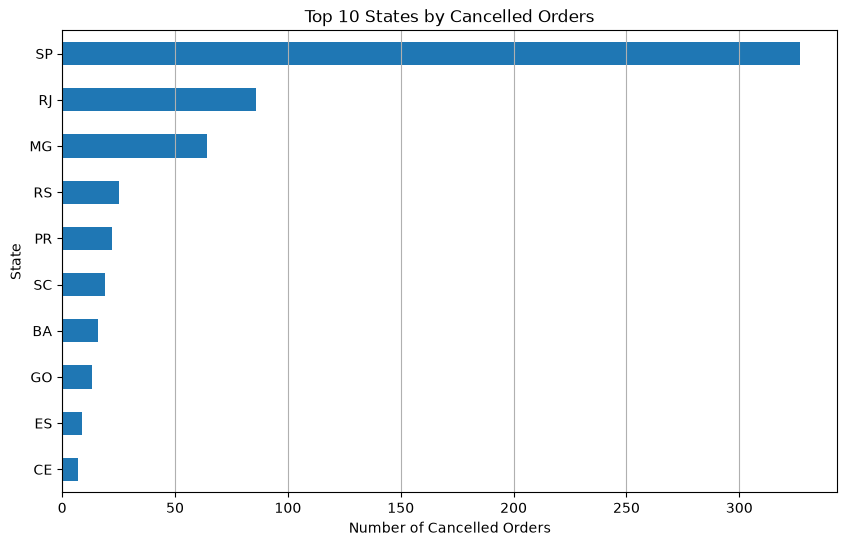

In [111]:
cancellation_by_state.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 States by Cancelled Orders")
plt.xlabel("Number of Cancelled Orders")
plt.ylabel("State")
plt.grid(axis="x")

plt.savefig(
    "output/cancelled_orders_by_state.png",
    bbox_inches="tight"
)

plt.show()
plt.close()

# Key Insights

- The dataset contains 99,441 orders.
- The overall cancellation rate is only 0.63%, indicating that cancellations are relatively low.
- São Paulo (SP) has the highest number of customers and also generates the highest total revenue.
- Beauty and personal care (`beleza_saude`) is the highest-revenue product category among the analyzed categories.
- Credit cards are the dominant payment method and generate the largest payment revenue.
- The business shows a strong preference for single-payment transactions, while credit-card users account for most installment activity.
- Monthly orders and revenue generally increased over the observed period, with the strongest performance occurring around late 2017 and early 2018.
- Delivery time is negatively correlated with review score (correlation ≈ -0.33).
- Customers giving 5-star reviews received their orders in approximately 10.2 days on average, compared with approximately 20.8 days for 1-star reviews.
- The results suggest that faster delivery is associated with higher customer satisfaction.
- Cancelled orders are concentrated in the larger customer markets, particularly SP, RJ, and MG.

# Conclusion

This exploratory data analysis provides an overview of sales performance,
customer distribution, product categories, payment behavior, delivery
performance, and customer satisfaction in Brazilian e-commerce data.

The analysis shows that revenue is concentrated in major customer markets,
particularly São Paulo, while a small number of product categories contribute
a significant share of revenue. Credit cards are the dominant payment method,
and installment behavior varies considerably across payment types.

One of the most important findings is the relationship between delivery time
and customer satisfaction. Lower review scores are associated with longer
delivery times, indicating that improving delivery performance could
potentially contribute to better customer satisfaction.

Overall, the analysis highlights the importance of monitoring revenue trends,
regional performance, payment behavior, cancellations, and delivery
efficiency when making e-commerce business decisions.